# White blood cells segmentation

## Getting dataset from kaggle

In [2]:
# Create the .kaggle directory if it doesn't exist
!mkdir -p /root/.kaggle

# Move the kaggle.json file to the correct directory
!mv /content/kaggle.json /root/.kaggle/

# Set permissions for the kaggle.json file
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API credentials have been set up.")

Kaggle API credentials have been set up.


In [3]:
!kaggle datasets download -d jeetblahiri/bccd-dataset-with-mask

Dataset URL: https://www.kaggle.com/datasets/jeetblahiri/bccd-dataset-with-mask
License(s): unknown
 99% 2.12G/2.15G [00:30<00:00, 44.9MB/s]
100% 2.15G/2.15G [00:30<00:00, 76.5MB/s]


In [ ]:
!unzip *.zip

In [5]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset
from sklearn.cluster import KMeans

!pip install -q scikit-fuzzy
import skfuzzy as fuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 15.0 MB/s eta 0:00:00


## Pytorch Dataset

In [6]:
class BCCDDataset(Dataset):
    def __init__(self, root_dir, split="test"):
        self.root_dir = os.path.join(root_dir, split)
        self.image_dir = os.path.join(self.root_dir, "original")
        self.mask_dir = os.path.join(self.root_dir, "mask")

        self.images = sorted(os.listdir(self.image_dir))
        self.masks = sorted(os.listdir(self.mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)
        mask = (mask > 0).astype(np.float32)

        image = torch.tensor(image, dtype=torch.float32).permute(2,0,1) / 255.0
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [7]:
train_dataset = BCCDDataset("/content/BCCD Dataset with mask", split="train")
test_dataset = BCCDDataset("/content/BCCD Dataset with mask", split="test")

## K-Means

In [8]:
def kmeans_segmentation(image, k=3):
    h, w, c = image.shape
    pixels = image.reshape(-1, c)

    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pixels)

    return labels.reshape(h, w)

## Fuzzy C-Means

In [9]:
def fcm_segmentation(image, c=3):
    h, w, ch = image.shape
    pixels = image.reshape(-1, ch).T

    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        pixels, c=c, m=2, error=0.005, maxiter=500
    )

    labels = np.argmax(u, axis=0)
    return labels.reshape(h, w)

In [10]:
def dice_score(pred, target):
    pred = pred.flatten()
    target = target.flatten()
    intersection = (pred * target).sum()
    return (2. * intersection) / (pred.sum() + target.sum() + 1e-8)

In [11]:
def best_cluster_match(segmented, mask):
    """to map the cluster predicted to the ground turth cluster correctly"""
    best_dice = 0
    best_binary = None

    for cluster_id in np.unique(segmented):
        binary = (segmented == cluster_id).astype(np.float32)
        d = dice_score(binary, mask)

        if d > best_dice:
            best_dice = d
            best_binary = binary

    return best_binary, best_dice

In [12]:
from tqdm import tqdm

kmeans_scores = []
fcm_scores = []

num_samples = min(2, len(test_dataset))

for i in tqdm(range(num_samples), desc="Evaluating"):
    image, mask = test_dataset[i]

    image_np = image.permute(1,2,0).numpy()
    mask_np = mask.numpy()

    # KMeans
    k_out = kmeans_segmentation(image_np, k=3)
    k_binary, k_dice = best_cluster_match(k_out, mask_np)
    kmeans_scores.append(k_dice)

    # FCM
    f_out = fcm_segmentation(image_np, c=3)
    f_binary, f_dice = best_cluster_match(f_out, mask_np)
    fcm_scores.append(f_dice)

print("\nAverage Dice on Test Set")
print("KMeans:", np.mean(kmeans_scores))
print("FCM:", np.mean(fcm_scores))

Evaluating: 100%|██████████| 2/2 [01:49<00:00, 54.88s/it]


Average Dice on Test Set
KMeans: 0.77163565
FCM: 0.7629757


Boundary Accuracy evaluation

In [13]:
def get_boundary(mask):
    mask_uint8 = (mask * 255).astype(np.uint8)
    edges = cv2.Canny(mask_uint8, 100, 200)
    return edges / 255.0

def boundary_dice(pred_mask, gt_mask):
    pred_edge = get_boundary(pred_mask)
    gt_edge = get_boundary(gt_mask)
    return dice_score(pred_edge, gt_edge)

def evaluate(dataset, num_samples=50):
    region_kmeans = []
    region_fcm = []

    boundary_kmeans = []
    boundary_fcm = []

    num_samples = min(num_samples, len(dataset))

    for i in tqdm(range(num_samples), desc="Evaluating"):
        image, mask = dataset[i]

        image_np = image.permute(1,2,0).numpy()
        mask_np = mask.numpy()

        # ---- KMEANS ----
        k_out = kmeans_segmentation(image_np, k=3)
        k_binary, k_region_dice = best_cluster_match(k_out, mask_np)
        region_kmeans.append(k_region_dice)

        k_boundary_dice = boundary_dice(k_binary, mask_np)
        boundary_kmeans.append(k_boundary_dice)

        # ---- FCM ----
        f_out = fcm_segmentation(image_np, c=3)
        f_binary, f_region_dice = best_cluster_match(f_out, mask_np)
        region_fcm.append(f_region_dice)

        f_boundary_dice = boundary_dice(f_binary, mask_np)
        boundary_fcm.append(f_boundary_dice)

    print("\n===== Average Results =====")
    print("Region Dice")
    print("KMeans:", np.mean(region_kmeans))
    print("FCM   :", np.mean(region_fcm))

    print("\nBoundary Dice")
    print("KMeans:", np.mean(boundary_kmeans))
    print("FCM   :", np.mean(boundary_fcm))

    return {
        "region_kmeans": np.mean(region_kmeans),
        "region_fcm": np.mean(region_fcm),
        "boundary_kmeans": np.mean(boundary_kmeans),
        "boundary_fcm": np.mean(boundary_fcm),
    }


In [14]:
results = evaluate(test_dataset, num_samples=2)

Evaluating: 100%|██████████| 2/2 [01:42<00:00, 51.09s/it]


===== Average Results =====
Region Dice
KMeans: 0.77163565
FCM   : 0.7629763

Boundary Dice
KMeans: 0.04817830650537336
FCM   : 0.046280507428288875


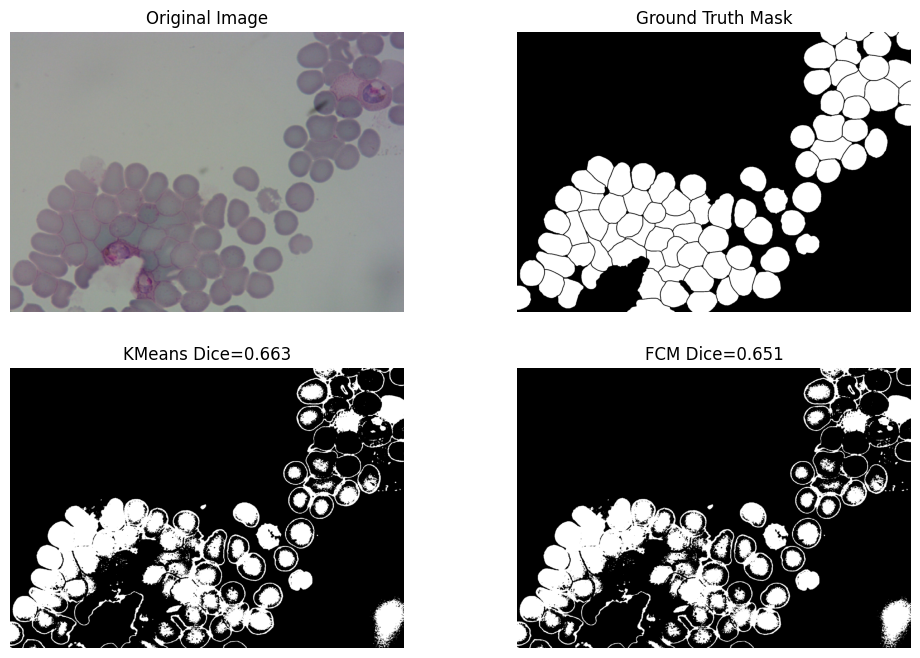

In [15]:
example_idx = 0

image, mask = test_dataset[example_idx]

image_np = image.permute(1,2,0).numpy()
mask_np = mask.numpy()

k_out = kmeans_segmentation(image_np, k=3)
k_binary, k_dice = best_cluster_match(k_out, mask_np)

f_out = fcm_segmentation(image_np, c=3)
f_binary, f_dice = best_cluster_match(f_out, mask_np)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(mask_np, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(k_binary, cmap="gray")
plt.title(f"KMeans Dice={k_dice:.3f}")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(f_binary, cmap="gray")
plt.title(f"FCM Dice={f_dice:.3f}")
plt.axis("off")

plt.show()

In [16]:
def colorize_clusters(segmented):
    h, w = segmented.shape
    colored = np.zeros((h, w, 3))

    colors = {
        0: [1, 0, 0],   # Red
        1: [0, 1, 0],   # Green
        2: [0, 0, 1],   # Blue
    }

    for cluster_id in np.unique(segmented):
        colored[segmented == cluster_id] = colors[cluster_id]

    return colored

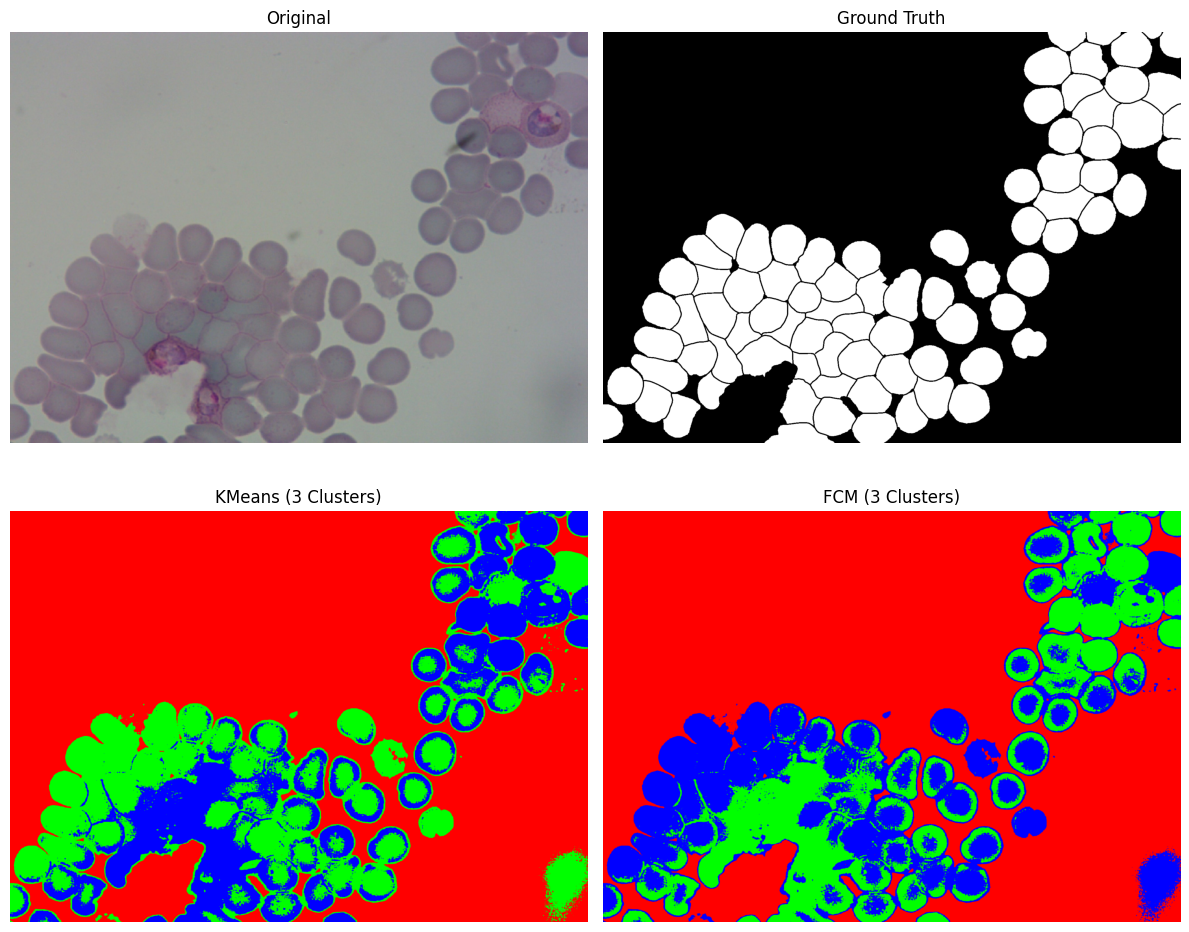

In [19]:
k_colored = colorize_clusters(k_out)
f_colored = colorize_clusters(f_out)

plt.figure(figsize=(12,10)) # Adjusted figure size for better 2x2 display

plt.subplot(2,2,1)
plt.imshow(image_np)
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(mask_np, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(k_colored)
plt.title("KMeans (3 Clusters)")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(f_colored)
plt.title("FCM (3 Clusters)")
plt.axis("off")

plt.tight_layout() # Added for better spacing
plt.show()